# 03 — Exploratory data analysis

**Inputs:** `data/analysis_panel_wages.csv`
**Function:** describe the outcome, the predictors, and the wage block; produce the eight descriptive figures
**Outputs:** `output/figures/01`–`05`, `10`–`12`; `output/tables/eda_*.csv`

FY2023 is a partial-year extract. It is kept in the descriptive time series, clearly
flagged, and excluded everywhere a model is fitted.

In [1]:
import sys
from pathlib import Path

# Locate the repository root by walking up until code/src is found, then put the
# code directory on the path. No absolute paths, so this runs from any checkout.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "code" / "src").is_dir())
sys.path.insert(0, str(_root / "code"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import (DATA, TABLES, MODEL_YEARS, finish, save,
                 C1, C2, SEQ, INK, INK2, SURFACE, describe_frame)

In [2]:
panel = pd.read_csv(DATA / "analysis_panel_wages.csv", low_memory=False)
describe_frame(panel, "joined analysis panel", keys=["employer", "fy"])

eda = panel.copy()                                   # all years, descriptive only
fit_df = panel[panel.fy.isin(MODEL_YEARS)].copy()    # FY2017-FY2022, modelling window
matched = panel.lca_filings.notna()                  # rows carrying a wage block

print(f"\ndescriptive rows: {len(eda):,}")
print(f"modelling-window rows: {len(fit_df):,}")
print(f"rows with wage data: {matched.sum():,} ({matched.mean():.1%})")

--- joined analysis panel ---
    rows: 184,301   columns: 36
    distinct employer: 107,466
    distinct fy: 7
    columns with missing values: 14 (worst: prev_denials at 58.8%)

descriptive rows: 184,301
modelling-window rows: 172,993
rows with wage data: 125,678 (68.2%)


## 1. The outcome over time

This is the dominant fact in the dataset: close to an order of magnitude of movement in
six years, with initial and continuing petitions tracking each other at roughly 2:1. The
timing matches the *Buy American, Hire American* adjudication posture and its unwinding
after the 2020 *ITServe Alliance v. Cissna* settlement.

findfont: Failed to find font weight 600, now using 700.


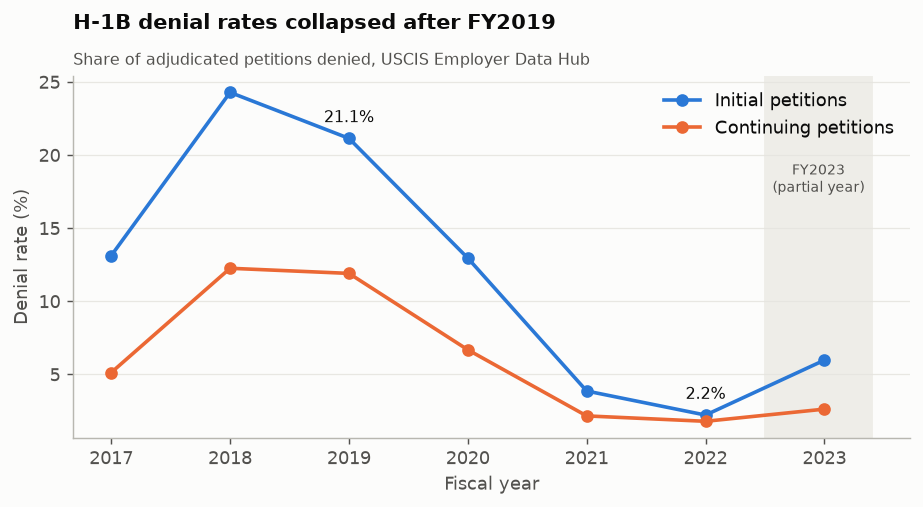

      initial_denial_rate  continuing_denial_rate
fy                                               
2017               0.1312                  0.0512
2018               0.2428                  0.1225
2019               0.2113                  0.1190
2020               0.1295                  0.0668
2021               0.0386                  0.0216
2022               0.0221                  0.0179
2023               0.0597                  0.0262


In [3]:
COUNTS = ["initial_approvals", "initial_denials",
          "continuing_approvals", "continuing_denials"]

yr = eda.groupby("fy")[COUNTS].sum()
yr["initial_denial_rate"] = yr.initial_denials / (yr.initial_approvals + yr.initial_denials)
yr["continuing_denial_rate"] = yr.continuing_denials / (
    yr.continuing_approvals + yr.continuing_denials)

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(yr.index, yr.initial_denial_rate * 100, color=C1, marker="o",
        markersize=6, label="Initial petitions")
ax.plot(yr.index, yr.continuing_denial_rate * 100, color=C2, marker="o",
        markersize=6, label="Continuing petitions")
for x in (2019, 2022):
    y = yr.loc[x, "initial_denial_rate"] * 100
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color=INK)
ax.axvspan(2022.5, 2023.4, color="#eeede8", zorder=0)
ax.text(2022.95, yr.initial_denial_rate.max() * 100 * 0.72,
        "FY2023\n(partial year)", ha="center", fontsize=8, color=INK2)
ax.legend(loc="upper right")
finish(ax, "H-1B denial rates collapsed after FY2019",
       "Share of adjudicated petitions denied, USCIS Employer Data Hub",
       "Fiscal year", "Denial rate (%)")
save("01_denial_rate_timeseries")

yr.round(4).to_csv(TABLES / "eda_denial_rate_by_year.csv")
print(yr[["initial_denial_rate", "continuing_denial_rate"]].round(4).to_string())

## 2. Distributions of the continuous predictors

All three are log-scaled on the count axis. The left panel is the key one: the outcome
has enormous mass at exactly zero, which is what motivates fitting a binary classifier
alongside the continuous rate in `04_models`.

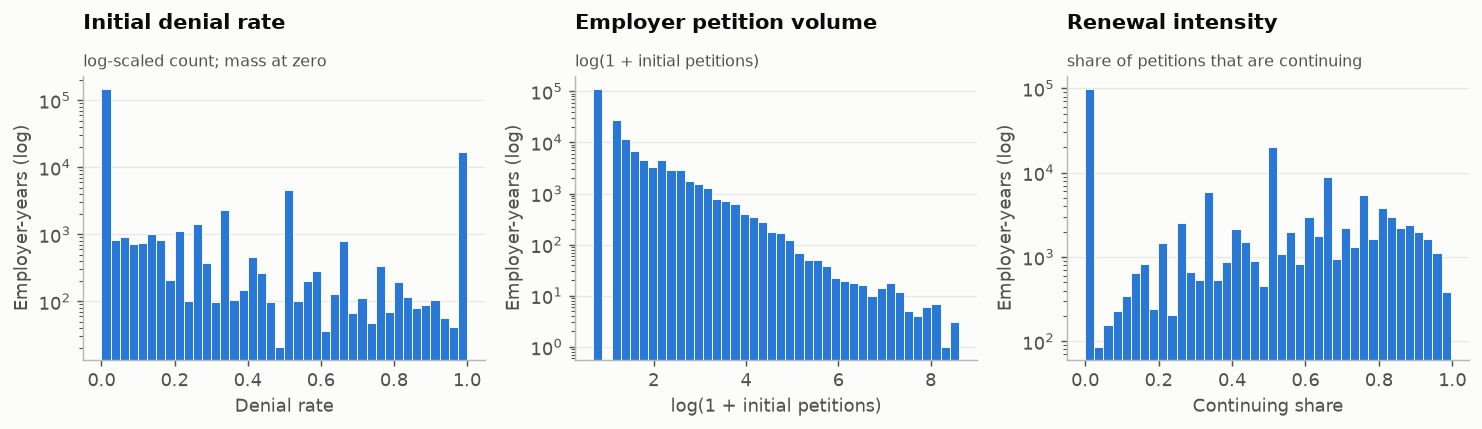

       denial_rate  log_initial  continuing_share  prev_denial_rate  years_active
count   184301.000   184301.000        184301.000        184301.000    184301.000
mean         0.128        1.101             0.272             0.043         3.387
std          0.304        0.715             0.323             0.168         2.236
min          0.000        0.693             0.000             0.000         1.000
25%          0.000        0.693             0.000             0.000         1.000
50%          0.000        0.693             0.000             0.000         3.000
75%          0.000        1.099             0.500             0.000         5.000
max          1.000        8.612             0.996             1.000         7.000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
axes[0].hist(eda.denial_rate, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[0].set_yscale("log")
finish(axes[0], "Initial denial rate", "log-scaled count; mass at zero",
       "Denial rate", "Employer-years (log)")

axes[1].hist(eda.log_initial, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[1].set_yscale("log")
finish(axes[1], "Employer petition volume", "log(1 + initial petitions)",
       "log(1 + initial petitions)", "Employer-years (log)")

axes[2].hist(eda.continuing_share, bins=40, color=SEQ, edgecolor=SURFACE, lw=0.5)
axes[2].set_yscale("log")
finish(axes[2], "Renewal intensity", "share of petitions that are continuing",
       "Continuing share", "Employer-years (log)")
save("02_histograms")

print(eda[["denial_rate", "log_initial", "continuing_share",
           "prev_denial_rate", "years_active"]].describe().round(3).to_string())

## 3. Industry

Professional/scientific/technical services — where IT consulting sits — carries both the
plurality of petitions and by far the highest denial rate.

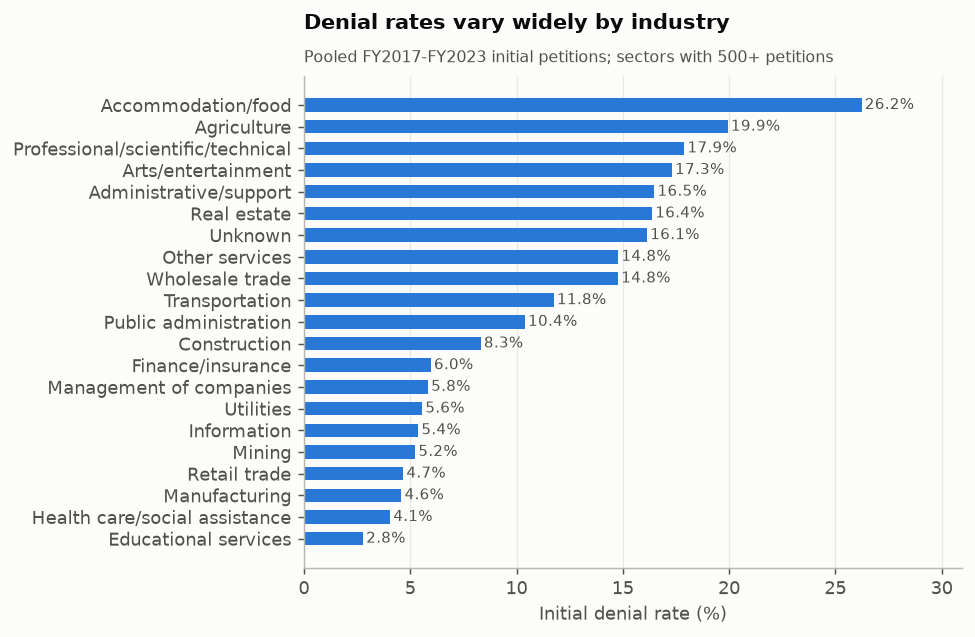

                                       n  initial  denials   rate
sector                                                           
Professional/scientific/technical  83242   481101    86075  17.89
Educational services               12129    82761     2300   2.78
Manufacturing                      20073    75404     3457   4.58
Information                         9879    51941     2792   5.38
Finance/insurance                  10663    42800     2554   5.97
Health care/social assistance      16044    41605     1687   4.05
Retail trade                        4351    37532     1753   4.67
Administrative/support              2717    10138     1671  16.48
Wholesale trade                     4880     8014     1184  14.77
Unknown                             5345     7076     1142  16.14
Construction                        3724     5989      498   8.32
Transportation                      1615     3548      417  11.75
Other services                      2186     3186      471  14.78
Real estat

In [5]:
sec = (eda.groupby("sector")
       .agg(n=("denial_rate", "size"),
            initial=("initial_total", "sum"),
            denials=("initial_denials", "sum"))
       .assign(rate=lambda t: t.denials / t.initial * 100)
       .query("initial >= 500").sort_values("rate"))

fig, ax = plt.subplots(figsize=(7.6, 5))
bars = ax.barh(sec.index, sec.rate, color=SEQ, height=0.62)
for b, v in zip(bars, sec.rate):
    ax.text(v + 0.15, b.get_y() + b.get_height() / 2, f"{v:.1f}%",
            va="center", fontsize=8.5, color=INK2)
ax.set_xlim(0, sec.rate.max() * 1.18)
finish(ax, "Denial rates vary widely by industry",
       "Pooled FY2017-FY2023 initial petitions; sectors with 500+ petitions",
       "Initial denial rate (%)", None, grid="x")
save("03_sector_bars")

sec.round(3).to_csv(TABLES / "eda_sector.csv")
print(sec.sort_values("initial", ascending=False).round(2).to_string())

## 4. Employer concentration

Mayda et al. (2020) document sponsorship concentrating in a narrow set of organisational
gatekeepers. That pattern is visible here directly.

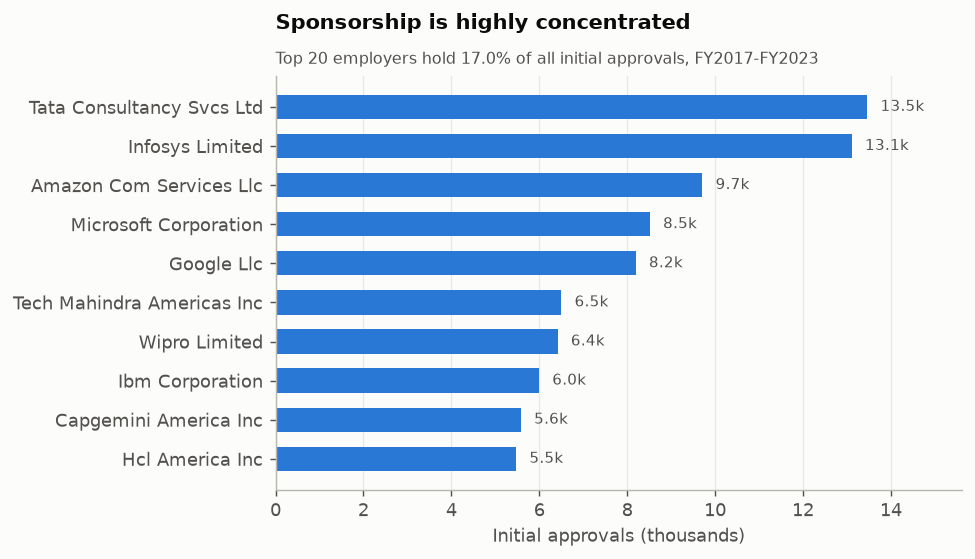

Top-20 employer share of initial approvals: 17.0%
employer
TATA CONSULTANCY SVCS LTD                 13462
INFOSYS LIMITED                           13110
AMAZON COM SERVICES LLC                    9711
MICROSOFT CORPORATION                      8516
GOOGLE LLC                                 8194
TECH MAHINDRA AMERICAS INC                 6503
WIPRO LIMITED                              6418
IBM CORPORATION                            5995
CAPGEMINI AMERICA INC                      5582
HCL AMERICA INC                            5475
FACEBOOK INC                               5472
ACCENTURE LLP                              5386
APPLE INC                                  5327
COGNIZANT TECH SOLNS US CORP               5295
INTEL CORPORATION                          5132
DELOITTE CONSULTING LLP                    4876
AMAZON.COM SERVICES LLC                    4297
COGNIZANT TECHNOLOGY SOLUTIONS US CORP     3568
COGNIZANT TECHNOLOGY SOLUTIONS US          3483
AMAZON.COM SERVICES INC      

In [6]:
top = eda.groupby("employer").initial_approvals.sum().sort_values(ascending=False)
share_top20 = top.head(20).sum() / top.sum() * 100

fig, ax = plt.subplots(figsize=(7.6, 4.4))
t10 = top.head(10).sort_values()
bars = ax.barh([e.title()[:34] for e in t10.index], t10.values / 1000,
               color=SEQ, height=0.62)
for b, v in zip(bars, t10.values / 1000):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2, f"{v:.1f}k",
            va="center", fontsize=8.5, color=INK2)
ax.set_xlim(0, (t10.values / 1000).max() * 1.16)
finish(ax, "Sponsorship is highly concentrated",
       f"Top 20 employers hold {share_top20:.1f}% of all initial approvals, FY2017-FY2023",
       "Initial approvals (thousands)", None, grid="x")
save("04_top_employers")

print(f"Top-20 employer share of initial approvals: {share_top20:.1f}%")
print(top.head(20).to_string())

## 5. Employer size

Larger sponsors are denied less often — the screening-logic implication from Spence, and
the reason `log_initial` and the sponsorship-history features carry so much weight in
`04_models`.

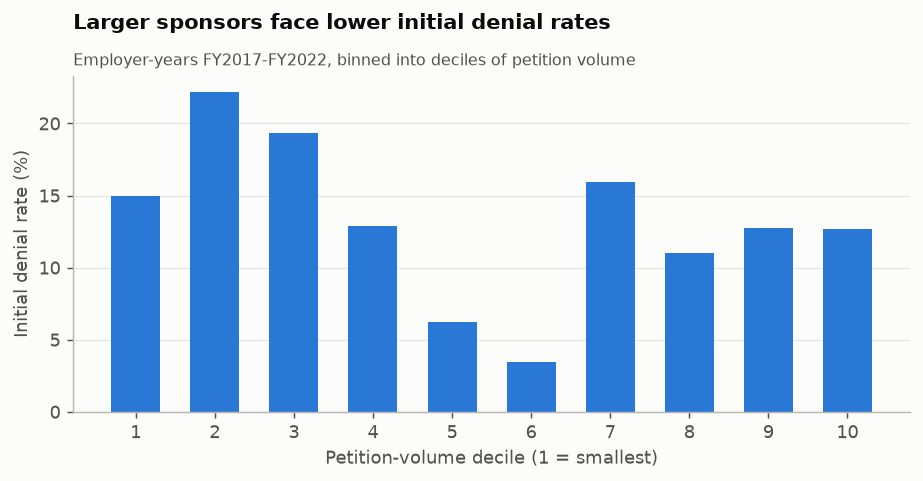

              rate  median_size
size_decile                    
1            14.99          1.0
2            22.19          1.0
3            19.37          1.0
4            12.86          1.0
5             6.21          1.0
6             3.44          1.0
7            15.90          2.0
8            10.99          2.0
9            12.77          4.0
10           12.66         13.0


In [7]:
fit_df["size_decile"] = pd.qcut(fit_df.initial_total.rank(method="first"),
                                10, labels=False) + 1
sz = fit_df.groupby("size_decile").apply(
    lambda t: pd.Series({
        "rate": t.initial_denials.sum() / t.initial_total.sum() * 100,
        "median_size": t.initial_total.median()}), include_groups=False)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(sz.index, sz.rate, color=SEQ, width=0.62)
ax.set_xticks(range(1, 11))
finish(ax, "Larger sponsors face lower initial denial rates",
       "Employer-years FY2017-FY2022, binned into deciles of petition volume",
       "Petition-volume decile (1 = smallest)", "Initial denial rate (%)")
save("05_size_decile")

sz.round(3).to_csv(TABLES / "eda_size_decile.csv")
print(sz.round(2).to_string())

## 6. The wage block

Everything below uses matched rows only — the 72.6% of modelling-window employer-years
that carry a DOL wage block. See `02_merge` for who fails to match and why it matters.

### 6.1 Offered wage relative to prevailing wage

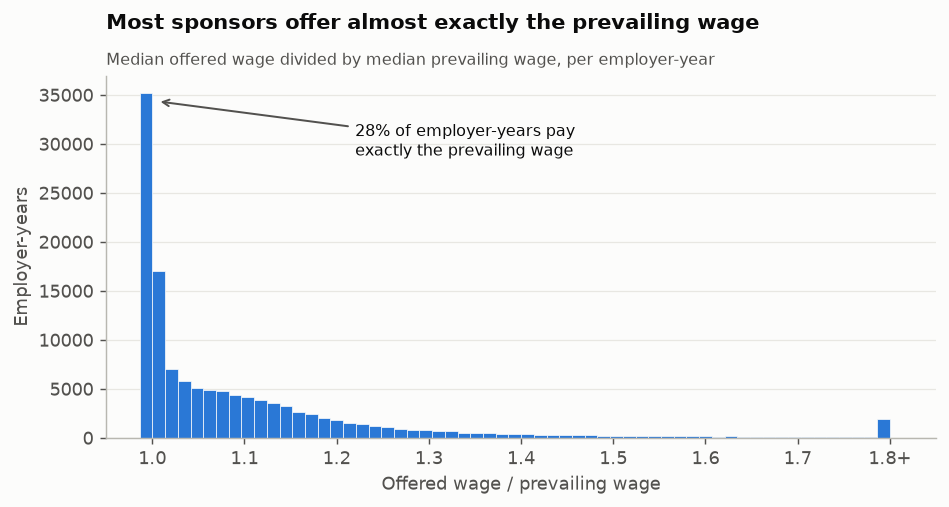

Median employer-year wage ratio: 1.036
Share at or below the prevailing wage: 27.9%


In [8]:
wage_df = panel
wr_raw = wage_df.loc[matched, "wage_ratio_med"].dropna()
at_prevailing = (wr_raw <= 1.0001).mean() * 100
wr = wr_raw.clip(upper=1.8)

fig, ax = plt.subplots(figsize=(7.4, 4))
ax.hist(wr, bins=64, color=SEQ, edgecolor=SURFACE, lw=0.4)
ax.annotate(f"{at_prevailing:.0f}% of employer-years pay\nexactly the prevailing wage",
            xy=(1.005, ax.get_ylim()[1] * 0.93),
            xytext=(1.22, ax.get_ylim()[1] * 0.78),
            fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1.1))
ax.set_xlim(0.95, 1.85)
ax.set_xticks([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8])
ax.set_xticklabels(["1.0", "1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7", "1.8+"])
finish(ax, "Most sponsors offer almost exactly the prevailing wage",
       "Median offered wage divided by median prevailing wage, per employer-year",
       "Offered wage / prevailing wage", "Employer-years")
save("10_wage_ratio_hist")

print(f"Median employer-year wage ratio: {wr_raw.median():.3f}")
print(f"Share at or below the prevailing wage: {at_prevailing:.1f}%")

### 6.2 Prevailing-wage level mix

Costa and Hira (2020) report that 60% of FY2019 certified positions used the two lowest
prevailing wage levels. Position-weighted, this panel puts the figure higher still, and
it is stable across the whole period rather than a feature of one year.

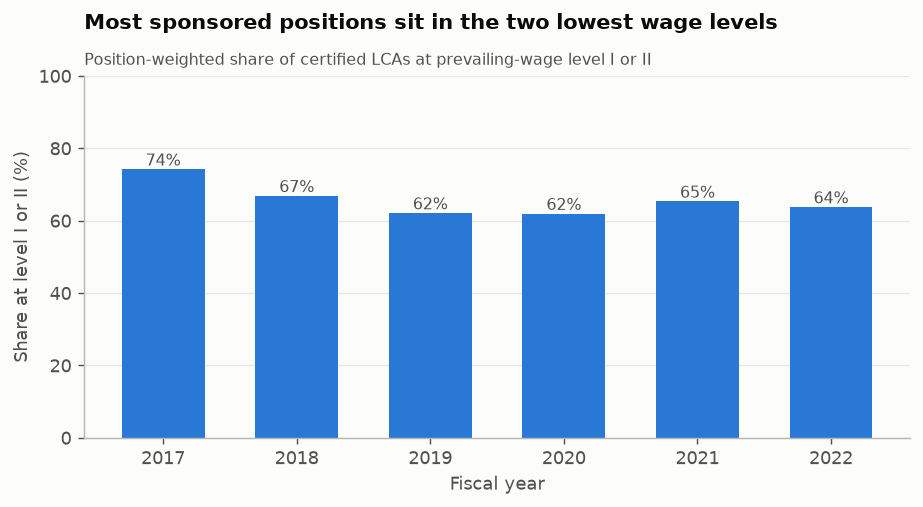

fy
2017    74.2
2018    66.9
2019    62.1
2020    62.0
2021    65.4
2022    63.8


In [9]:
byyr = (wage_df[matched].groupby("fy")
        .apply(lambda t: np.average(t.share_low_level.fillna(0),
                                    weights=t.lca_positions.fillna(1)),
               include_groups=False) * 100)

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.bar(byyr.index, byyr.values, color=SEQ, width=0.62)
for x, v in zip(byyr.index, byyr.values):
    ax.text(x, v + 1, f"{v:.0f}%", ha="center", fontsize=9, color=INK2)
ax.set_ylim(0, 100)
finish(ax, "Most sponsored positions sit in the two lowest wage levels",
       "Position-weighted share of certified LCAs at prevailing-wage level I or II",
       "Fiscal year", "Share at level I or II (%)")
save("11_wage_level_share")

byyr.round(1).to_csv(TABLES / "eda_wage_level_share.csv")
print(byyr.round(1).to_string())

### 6.3 Denial rate by wage band

A quarter of employer-years sit at a ratio of exactly 1.000, so rank-based deciles would
split that tie arbitrarily. Explicit bands are used instead. Only three employer-years
fall below 1.00, so they fold into the "at prevailing" band rather than forming a bar of
their own.

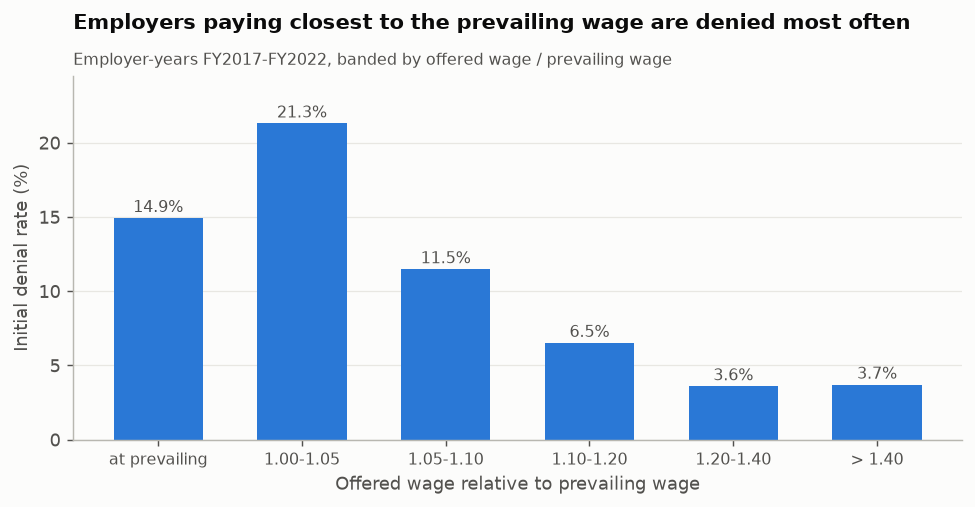

                 rate  employer_years
wr_band                              
at prevailing  14.930         34950.0
1.00-1.05      21.300         33218.0
1.05-1.10      11.479         17149.0
1.10-1.20       6.516         21707.0
1.20-1.40       3.594         12187.0
> 1.40          3.701          6216.0


In [10]:
m = wage_df[matched & wage_df.wage_ratio_med.notna()].copy()
EDGES = [0, 1.0001, 1.05, 1.10, 1.20, 1.40, np.inf]
LABELS = ["at prevailing", "1.00-1.05", "1.05-1.10",
          "1.10-1.20", "1.20-1.40", "> 1.40"]
m["wr_band"] = pd.cut(m.wage_ratio_med, bins=EDGES, labels=LABELS, include_lowest=True)

wd = m.groupby("wr_band", observed=True).apply(
    lambda t: pd.Series({
        "rate": t.initial_denials.sum() / t.initial_total.sum() * 100,
        "employer_years": len(t)}), include_groups=False)

fig, ax = plt.subplots(figsize=(7.6, 4))
ax.bar(range(len(wd)), wd.rate, color=SEQ, width=0.62)
for i, v in enumerate(wd.rate):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9, color=INK2)
ax.set_xticks(range(len(wd)))
ax.set_xticklabels(wd.index, fontsize=9)
ax.set_ylim(0, wd.rate.max() * 1.15)
finish(ax, "Employers paying closest to the prevailing wage are denied most often",
       "Employer-years FY2017-FY2022, banded by offered wage / prevailing wage",
       "Offered wage relative to prevailing wage", "Initial denial rate (%)")
save("12_denial_by_wage_band")

wd.round(3).to_csv(TABLES / "eda_denial_by_wage_band.csv")
print(wd.round(3).to_string())

This is a descriptive association, not a causal claim: employers who pay at the floor are
disproportionately the small, IT-staffing-style petitioners who also attract the most
adjudicator scrutiny. `04_models` tests whether the wage block still adds predictive
signal once size, history, sector and year are controlled for.

**Next:** `04_models.ipynb`.